In [1]:
import os
import sys

import json
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [2]:
if os.path.basename(os.getcwd()) == "notebooks":
    PROJECT_ROOT = os.path.abspath("..")
else:
    PROJECT_ROOT = os.getcwd()

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(PROJECT_ROOT)

/home/dantimson/ML_NLP/IAD25-ML-NLP-lab


In [ ]:
from src.preprocess import (
    ID2TAG,
    TAG2ID,
    load_conll_csv,
    build_sentence_examples,
    train_valid_split_balanced,
)

from src.metrics import entity_level_prf1

from src.crf import CRFNER

from src.tf import TransformerNER, TransformerConfig

from src.entity import EntityStore

from src.entity_ingest import ingest_examples, spans_from_iob

from src.visualize import highlight_entities_html, plot_category_wordcloud

In [4]:
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "outputs")
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

TRAIN_PATH = os.path.join(DATA_DIR, "train.csv")
TEST_PATH = os.path.join(DATA_DIR, "test.csv")

In [5]:
TRAIN_CRF = False
TRAIN_TF = False
SHOW_PROGRESS = True

CRF_CHECKPOINT = os.path.join(MODEL_DIR, "crf_ner.joblib")
TF_CHECKPOINT = os.path.join(MODEL_DIR, "distilbert_ner")

In [6]:
train_df = load_conll_csv(TRAIN_PATH, has_labels=True)
test_df = load_conll_csv(TEST_PATH, has_labels=False)

train_examples = build_sentence_examples(train_df, has_labels=True)
test_examples = build_sentence_examples(test_df, has_labels=False)

print(len(train_df), len(test_df))
print(len(train_examples), len(test_examples))
train_df.head()

839364 209211
38367 9592


,row_id,Sentence_id,Word,POS,Tag,Tag_str
0,0,1,Thousands,NNS,0,O
1,1,1,of,IN,0,O
2,2,1,demonstrators,NNS,0,O
3,3,1,have,VBP,0,O
4,4,1,marched,VBN,0,O


In [7]:
tag_counts = train_df["Tag_str"].value_counts()
tag_counts

Tag_str
O        710524
B-geo     30338
B-tim     16239
B-org     16140
I-per     13903
B-per     13573
I-org     13462
B-gpe     12662
I-geo      5987
I-tim      5152
B-art       321
B-eve       252
I-art       241
I-eve       206
B-nat       164
I-gpe       155
I-nat        45
Name: count, dtype: int64

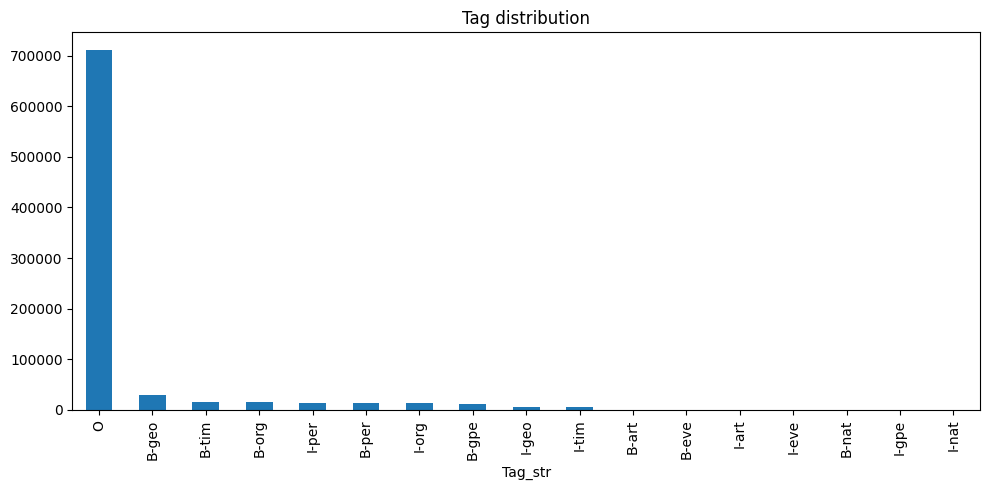

In [8]:
plt.figure(figsize=(10, 5))
tag_counts.plot(kind="bar")
plt.title("Tag distribution")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "tag_distribution.png"))
plt.show()

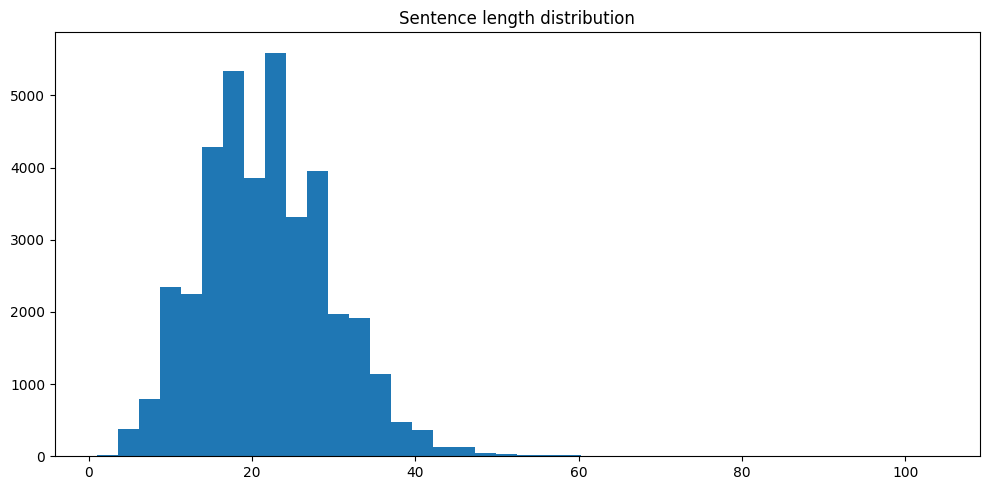

In [9]:
sentence_lengths = [len(ex.tokens) for ex in train_examples]

plt.figure(figsize=(10, 5))
plt.hist(sentence_lengths, bins=40)
plt.title("Sentence length distribution")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "sentence_length_distribution.png"))
plt.show()

In [ ]:
train_split, valid_split = train_valid_split_balanced(
    train_examples,
    valid_size=0.2,
    random_state=42,
)

len(train_split), len(valid_split)

(30693, 7674)

In [11]:
crf_model = CRFNER(show_progress=SHOW_PROGRESS)

if TRAIN_CRF or not os.path.exists(CRF_CHECKPOINT):
    print("Training CRF...")
    crf_model.fit(train_split)
    crf_model.save(CRF_CHECKPOINT)
else:
    print("Loading CRF from checkpoint...")
    crf_model.load(CRF_CHECKPOINT)

crf_pred = crf_model.predict(valid_split)
y_true = [x.ner_tags for x in valid_split]

crf_scores = entity_level_prf1(y_true, crf_pred)
crf_scores

Training CRF...


CRF labels: 100%|██████████| 30693/30693 [00:00<00:00, 1180195.94it/s]


Fitting CRF...


CRF predict features: 100%|██████████| 7674/7674 [00:00<00:00, 14896.69it/s]


{'precision': 0.8508826001681143,
 'recall': 0.8393587617468214,
 'f1': 0.8450813969667456,
 'tp': 15184,
 'fp': 2661,
 'fn': 2906}

In [ ]:
# tf_config = TransformerConfig(
#     model_name="distilbert-base-cased",
#     max_length=128,
#     output_dir=TF_CHECKPOINT,
#     learning_rate=2e-5,
#     train_batch_size=16,
#     eval_batch_size=16,
#     num_train_epochs=3,
#     show_progress=SHOW_PROGRESS,
# )

tf_config = TransformerConfig(
    model_name="bert-base-cased",
    max_length=128,
    output_dir=TF_CHECKPOINT,
    learning_rate=2e-5,
    train_batch_size=8,
    eval_batch_size=8,
    num_train_epochs=4,
    show_progress=SHOW_PROGRESS,
)

tf_model = TransformerNER(tf_config)

checkpoint_exists = os.path.exists(TF_CHECKPOINT) and os.path.exists(os.path.join(TF_CHECKPOINT, "config.json"))

if TRAIN_TF or not checkpoint_exists:
    print("Training transformer...")
    tf_model.fit(train_split, valid_split, do_train=True)
else:
    print("Loading transformer from checkpoint...")
    tf_model.load(TF_CHECKPOINT)

tf_pred = tf_model.predict(valid_split)
tf_scores = entity_level_prf1(y_true, tf_pred)
tf_scores

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1158.60it/s]
DistilBertForTokenClassification LOAD REPORT from: distilbert-base-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading transformer from checkpoint...


Transformer predict: 100%|██████████| 7674/7674 [01:40<00:00, 76.62it/s] 


{'precision': 0.8268821313533876,
 'recall': 0.8372581536760642,
 'f1': 0.8320377949295467,
 'tp': 15146,
 'fp': 3171,
 'fn': 2944}

In [15]:
comparison = pd.DataFrame([
    {"model": "CRF", **crf_scores},
    {"model": "DistilBERT", **tf_scores},
])
comparison

,model,precision,recall,f1,tp,fp,fn
0,CRF,0.850883,0.839359,0.845081,15184,2661,2906
1,DistilBERT,0.826882,0.837258,0.832038,15146,3171,2944


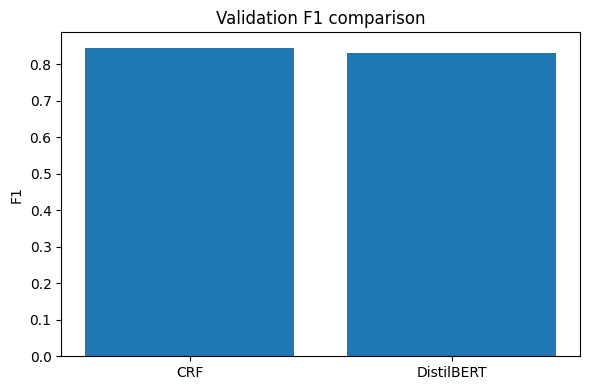

In [16]:
plt.figure(figsize=(6, 4))
plt.bar(comparison["model"], comparison["f1"])
plt.title("Validation F1 comparison")
plt.ylabel("F1")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "model_f1_comparison.png"))
plt.show()

In [17]:
store = EntityStore()

best_name = "DistilBERT" if tf_scores["f1"] >= crf_scores["f1"] else "CRF"
best_pred = tf_pred if best_name == "DistilBERT" else crf_pred

ingest_examples(store, valid_split, best_pred, show_progress=SHOW_PROGRESS)

print("Best model:", best_name)
print("Entities:", len(store.entities))
print("Categories:", sorted(store.categories))

Ingest entities: 100%|██████████| 7674/7674 [00:00<00:00, 83070.10it/s]

Best model: CRF
Entities: 4980
Categories: ['art', 'eve', 'geo', 'gpe', 'nat', 'org', 'per', 'tim']


In [ ]:
def choose_best_sentence_pred(tf_tags, crf_tags):
    tf_has_entity = any(tag != "O" for tag in tf_tags)
    crf_has_entity = any(tag != "O" for tag in crf_tags)

    if not tf_has_entity and crf_has_entity:
        return crf_tags
    return tf_tags

blended_pred = [
    choose_best_sentence_pred(tf_seq, crf_seq)
    for tf_seq, crf_seq in zip(tf_pred, crf_pred)
]

In [18]:
store.add_entity("ChatGPT", "org", description="An AI assistant system.")
store.get_entity_overview("ChatGPT")

{'canonical_name': 'ChatGPT',
 'category': 'org',
 'description': 'An AI assistant system.',
 'aliases': [],
 'num_mentions': 0,
 'related_texts': []}

In [19]:
store.reassign_entity("ChatGPT", "art")
store.get_entity_overview("ChatGPT")

{'canonical_name': 'ChatGPT',
 'category': 'art',
 'description': 'An AI assistant system.',
 'aliases': [],
 'num_mentions': 0,
 'related_texts': []}

In [20]:
store.delete_entity("ChatGPT")
store.get_entity_overview("ChatGPT")

In [21]:
sample_entity = next(iter(store.entities.keys()))
store.get_entity_overview(sample_entity)

{'canonical_name': 'Bambang Hendarso Danuri',
 'category': 'per',
 'description': '',
 'aliases': [],
 'num_mentions': 1,
 'related_texts': ['National Police Chief Bambang Hendarso Danuri told reporters in Jakarta Friday the militants planned to declare a Muslim state after killing Mr. Yudhoyono , state officials and foreign guests during an independence day celebration on August 17 .']}

In [22]:
store.get_related_texts(sample_entity)[:3]

['National Police Chief Bambang Hendarso Danuri told reporters in Jakarta Friday the militants planned to declare a Muslim state after killing Mr. Yudhoyono , state officials and foreign guests during an independence day celebration on August 17 .']

In [23]:
store.explain_word(sample_entity)

"'Bambang Hendarso Danuri' is known as category 'per' with 1 stored mention(s)."

In [24]:
from IPython.display import HTML

idx = 0
HTML(highlight_entities_html(valid_split[idx].tokens, best_pred[idx]))

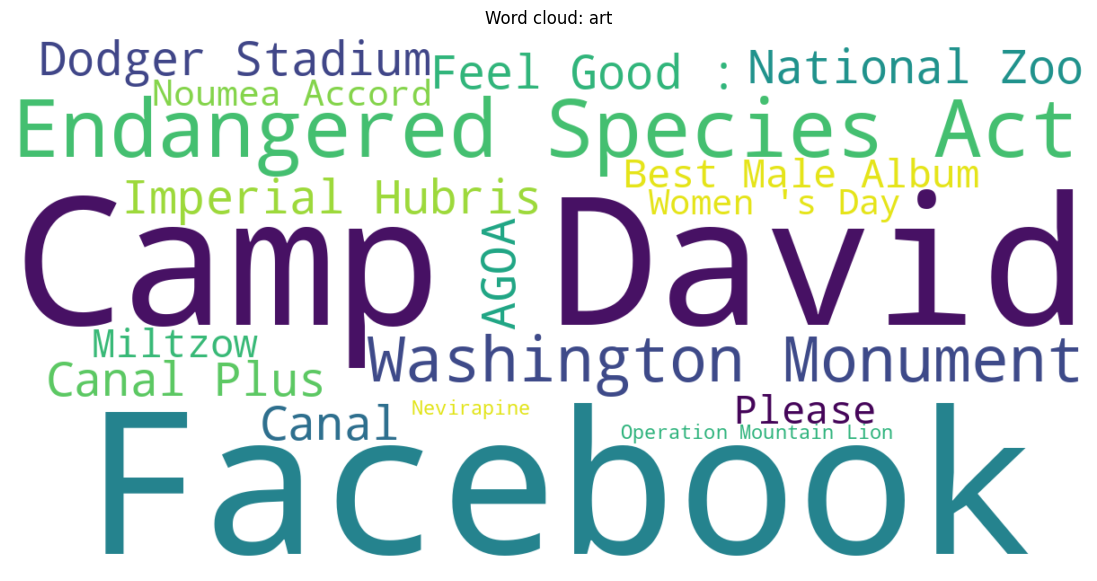

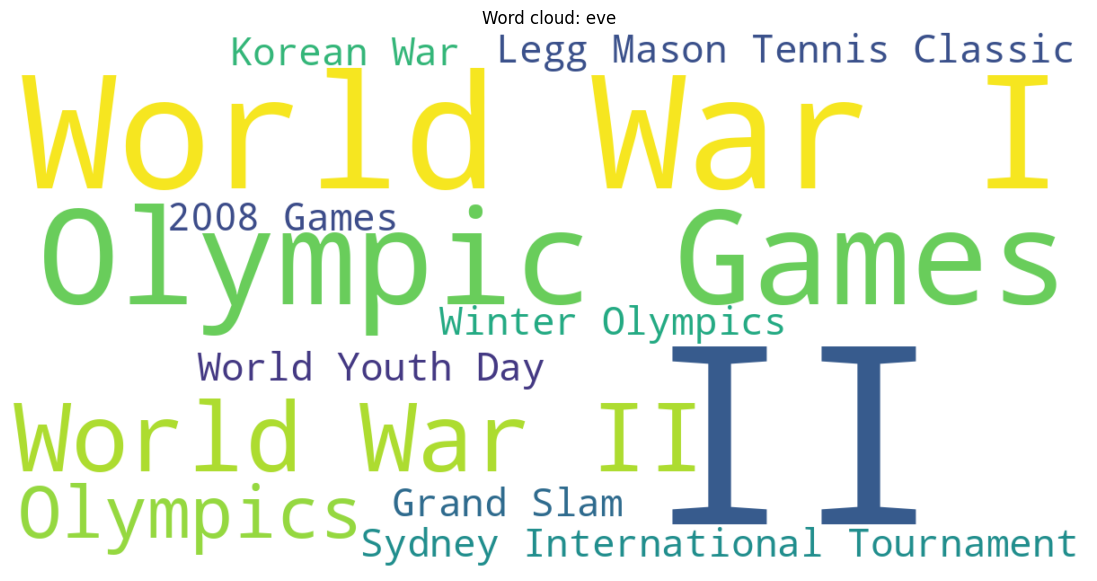

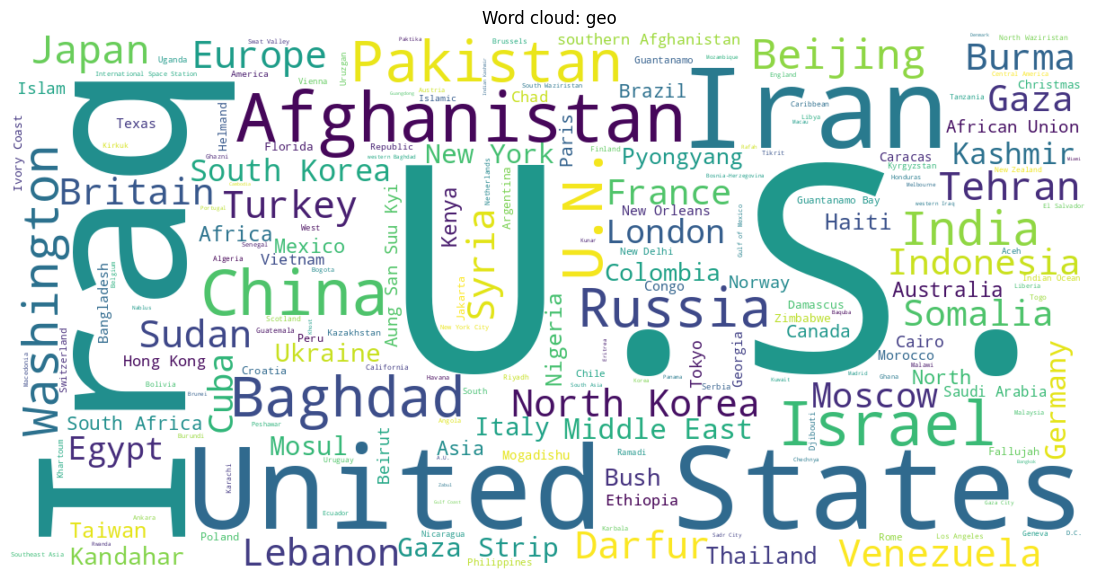

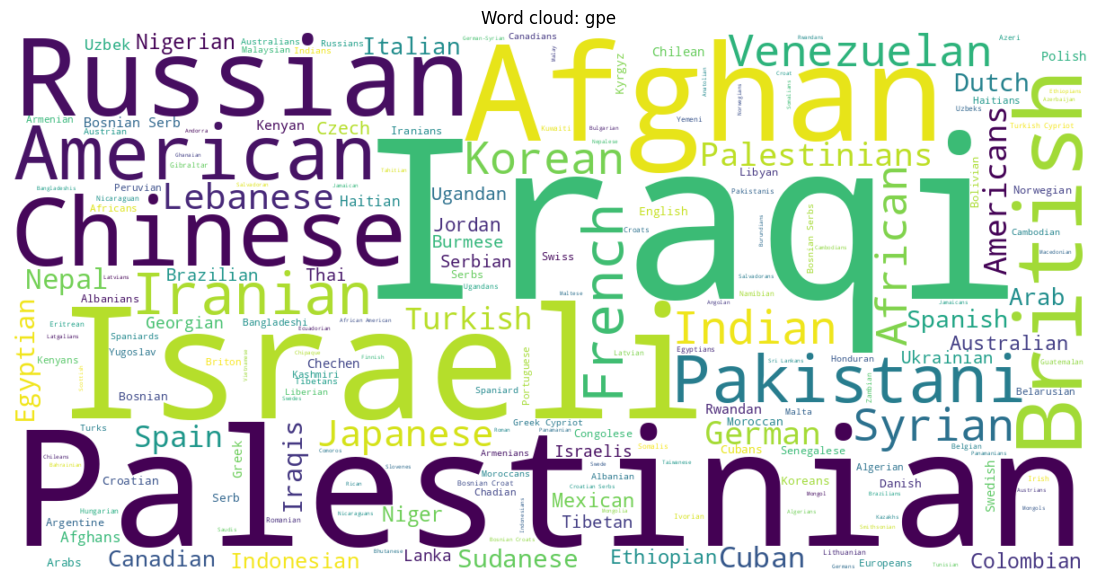

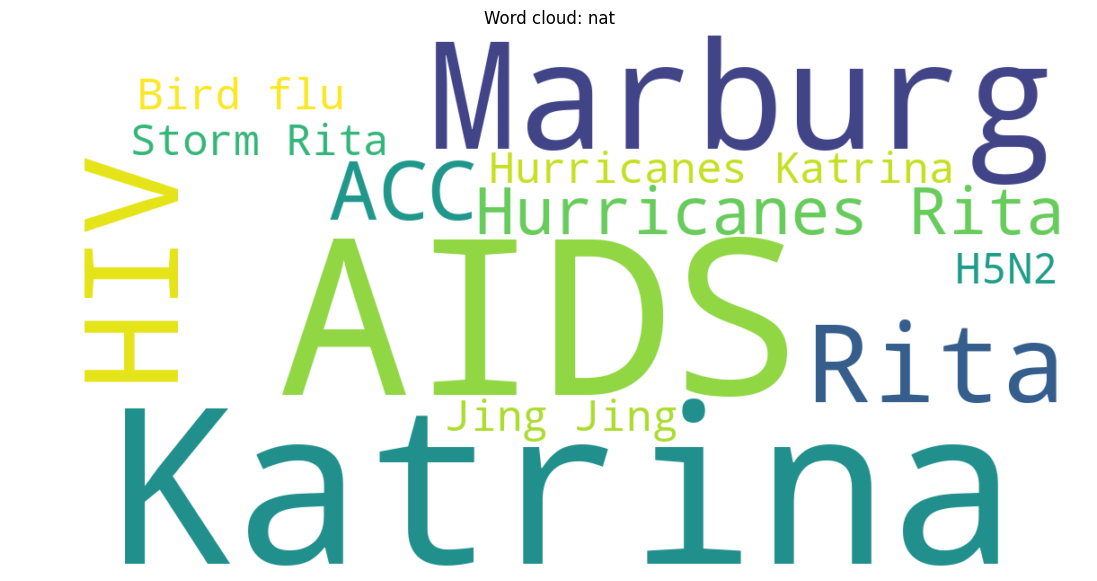

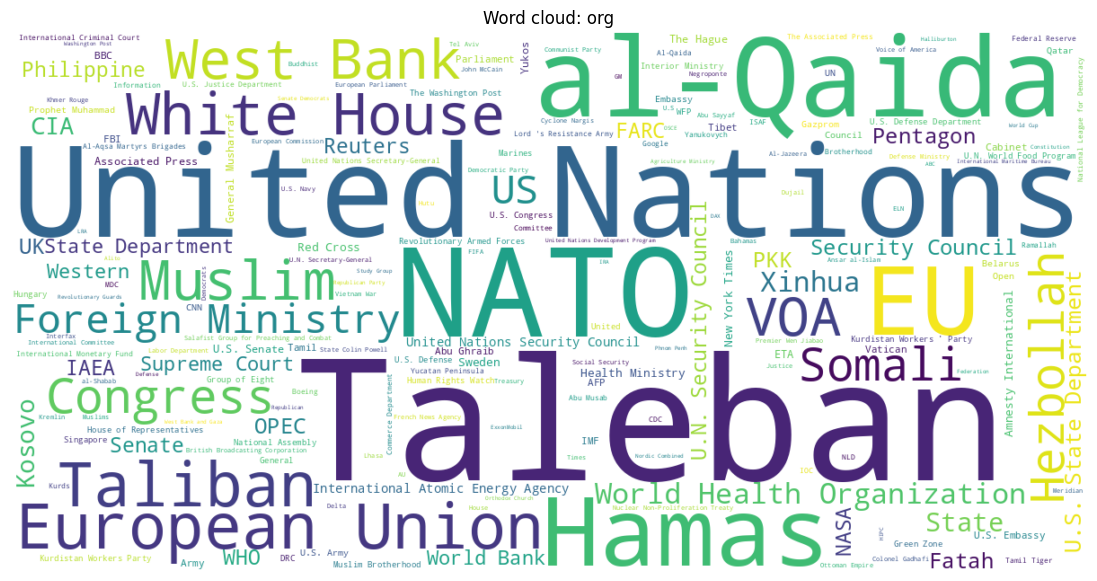

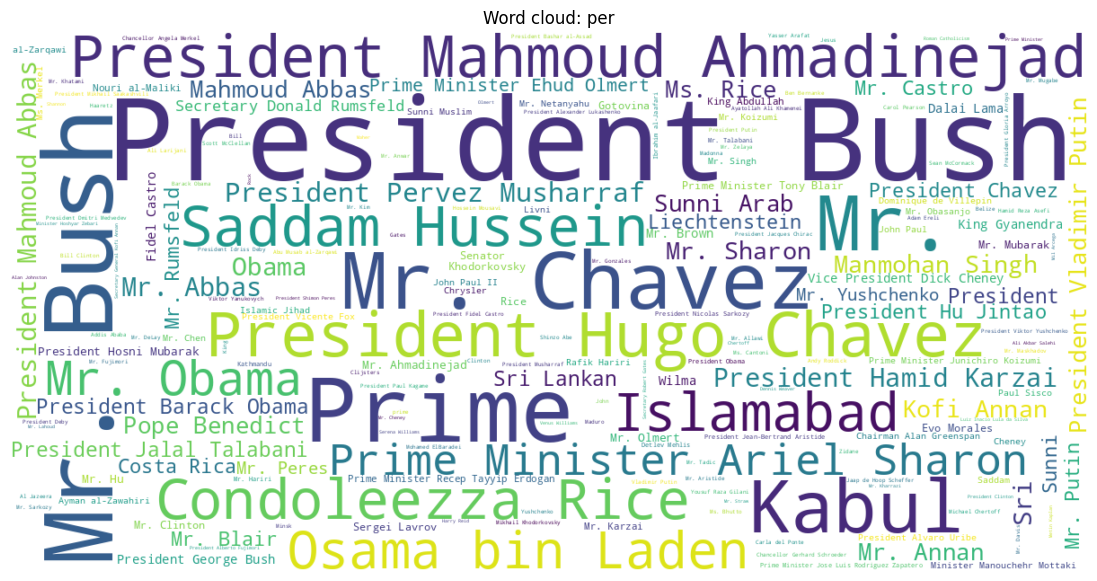

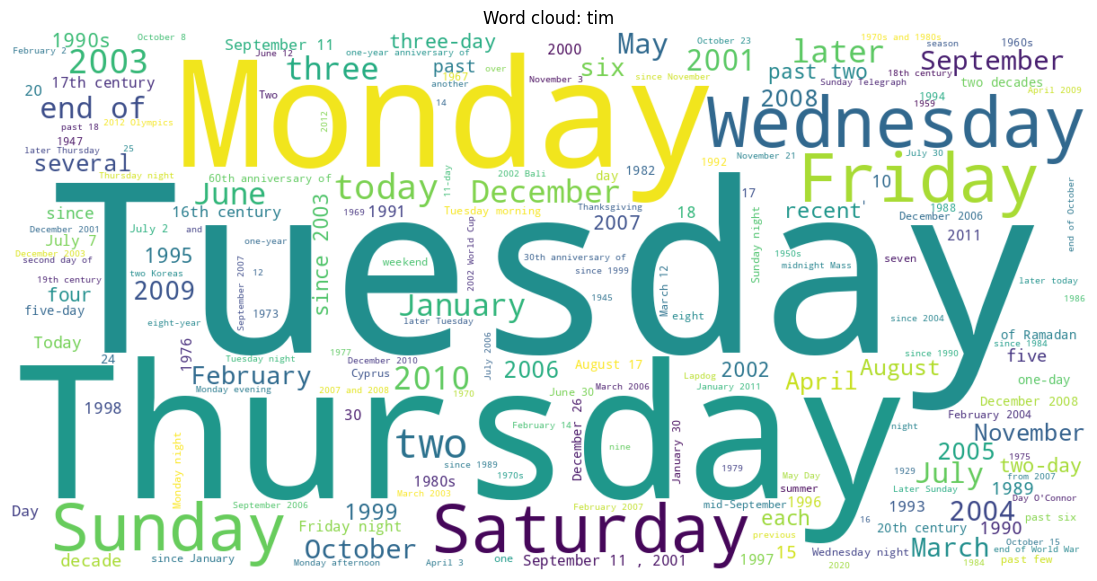

In [25]:
for cat in sorted(store.categories):
    plot_category_wordcloud(
        store,
        cat,
        save_path=os.path.join(FIG_DIR, f"wordcloud_{cat}.png"),
    )

In [26]:
if best_name == "DistilBERT":
    test_pred = tf_model.predict(test_examples)
else:
    test_pred = crf_model.predict(test_examples)

CRF predict features: 100%|██████████| 9592/9592 [00:00<00:00, 12325.43it/s]


In [27]:
rows = []
for ex, pred_tags in zip(test_examples, test_pred):
    pred_ids = [TAG2ID[tag] for tag in pred_tags]
    for row_id, pred_id in zip(ex.row_ids, pred_ids):
        rows.append({"ID": int(row_id), "TARGET": int(pred_id)})

submission = pd.DataFrame(rows).sort_values("ID").reset_index(drop=True)
submission.head()

,ID,TARGET
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0


In [29]:
len(submission), len(test_df)

(209211, 209211)

In [28]:
submission_path = os.path.join(OUTPUT_DIR, "submission.csv")
submission.to_csv(submission_path, index=False)
submission_path

'/home/dantimson/ML_NLP/IAD25-ML-NLP-lab/outputs/submission.csv'